In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
import numpy as np

# =========================
# 🔹 PADRÃO VISUAL DO TCC
# =========================

mpl.rcParams.update({
    # 🔹 Fonte
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],  # fallback se a 1ª não existir no sistema
    "mathtext.fontset": "stix",  # deixa fórmulas/matemática com aparência serifada compatível

    # 🔹 Tamanhos
    "font.size": 10,
    "axes.titlesize": 18,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
    "figure.titlesize": 25,

    # 🔹 Linhas e marcadores
    "lines.linewidth": 1.3,
    "lines.markersize": 4,

    # 🔹 Eixos e grid
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,

    # 🔹 Legenda
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "black",

    # 🔹 Exportação
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.dpi": 100,   # resolução na tela/notebook
})

# 🔹 paleta de cores consistente (colorblind-friendly)
PALETTE = {
    "Train": "#025C91",   # 
    "Val":   "#AD0283",   # 
    "Test":  "#5B02C0",   # 
    "Ref":   "black",
}

TITLE_LATEX = {
    "ZZxReto":   r"$ZZX_{reto}$",
    "ZZy1":      r"$ZZY_{1}$",
    "ZZx1":      r"$ZZX_{1}$",
    "ZZx2":      r"$ZZX_{2}$",
    "ZZy2":      r"$ZZY_{2}$",
    "ZZx1-inv":  r"$ZZX_{1}^{inv}$",
    "zzx2-inv2": r"$ZZX_{2}^{inv}$",
    "LSG-1":     r"$LSG_{1}$",
    "LSG-2":     r"$LSG_{2}$",
    "semiCirc":  r"$SCIRC$",
}

In [ ]:

# =========================
# 🔹 CONFIGURAÇÃO
# =========================

X_COL = "x"
Y_COL = "y"

FILE_PATH = "Datasets.xlsx"
OUTPUT_PDF = "trajetorias_referencia_vs_robo.pdf"

SETS_CATEGORY = {
    "ZZx1":   "Train",
    "ZZx2":      "Val",
    "ZZy1":      "Test",
    "LSG-1":     "Test",
    "LSG-2":     "Test",
    "ZZx1-inv":  "Test",
    "ZZy2":      "Test",
    "ZZxReto":    "Test",
    "zzx2-inv2": "Test",
    "semiCirc":  "Test",
}

CATEGORY_LABEL = {
    "Train": "Treinamento",
    "Val":   "Validação",
    "Test":  "Teste",
}

# =========================
# 🔹 TRAJETÓRIAS DE REFERÊNCIA (objVect)
# =========================

OBJ_VECTORS = {
    "ZZxReto": [
        (0.25,0),(0.5,0),(0.75,0),(1,0),(0.75,0.175),(0.5,0.35),(0.25,0.525),
        (0,0.7),(0.25,0.7),(0.5,0.7),(0.75,0.7),(1,0.7),(0.75,0.525),(0.5,0.35),
        (0.25,0.175),(0,0),(0.25,0),
    ],
    "ZZx1": [
        (0.0000,0.7000),(1.0000,0.7000),(0.8889,0.5829),(0.7778,0.4780),(0.6667,0.3842),
        (0.5556,0.3002),(0.4445,0.2251),(0.3333,0.1579),(0.2222,0.0978),(0.1111,0.0439),
        (0.0000,-0.0042),(1.0000,-0.0042),(0.8889,0.0439),(0.7778,0.0978),(0.6667,0.1579),
        (0.5556,0.2251),(0.4445,0.3002),(0.3333,0.3842),(0.2222,0.4780),(0.1111,0.5829),(0.0000,0.7000),
    ],
    "ZZy1": [
        (0.7000,0.0000),(0.7000,1.0000),(0.5829,0.8889),(0.4780,0.7778),(0.3842,0.6667),
        (0.3002,0.5556),(0.2251,0.4445),(0.1579,0.3333),(0.0978,0.2222),(0.0439,0.1111),
        (-0.0042,0.0000),(-0.0042,1.0000),(0.0439,0.8889),(0.0978,0.7778),(0.1579,0.6667),
        (0.2251,0.5556),(0.3002,0.4445),(0.3842,0.3333),(0.4780,0.2222),(0.5829,0.1111),(0.7000,0.0000),
    ],
    "ZZy2": [
        (-0.0000,0.7324),(-0.5020,0.6103),(-0.9199,0.4883),(-1.2679,0.3662),(-1.5578,0.2441),
        (-1.7991,0.1221),(-2.0000,0.0000),(-2.0000,0.7324),(-1.7991,0.6103),(-1.5578,0.4883),
        (-1.2679,0.3662),(-0.9199,0.2441),(-0.5020,0.1221),(-0.0000,0.0000),(-0.0000,0.7324),
    ],
    "ZZx1-inv": [
        (0.0000,0.0000),(1.0500,0.0000),(0.9333,0.1052),(0.8167,0.1993),(0.7000,0.2835),
        (0.5833,0.3588),(0.4667,0.4262),(0.3500,0.4866),(0.2333,0.5406),(0.1167,0.5889),
        (0.0000,0.6321),(1.0500,0.6321),(0.9333,0.5889),(0.8167,0.5406),(0.7000,0.4866),
        (0.5833,0.4262),(0.4667,0.3588),(0.3500,0.2835),(0.2333,0.1993),(0.1167,0.1052),
        (0.0000,0.0000),(0.0000,0.0000),
    ],
    "ZZx2": [
        (0.7324,-0.0000),(0.6103,-0.5020),(0.4883,-0.9199),(0.3662,-1.2679),(0.2441,-1.5578),
        (0.1221,-1.7991),(0.0000,-2.0000),(0.7324,-2.0000),(0.6103,-1.7991),(0.4883,-1.5578),
        (0.3662,-1.2679),(0.2441,-0.9199),(0.1221,-0.5020),(0.0000,-0.0000),
    ],
    "zzx2-inv2": [
        (0.7324,0.0000),(0.6103,0.5020),(0.4883,0.9199),(0.3662,1.2679),(0.2441,1.5578),
        (0.1221,1.7991),(0.0000,2.0000),(0.7324,2.0000),(0.6103,1.7991),(0.4883,1.5578),
        (0.3662,1.2679),(0.2441,0.9199),(0.1221,0.5020),(0.0000,0.0000),(0.7324,0.0000),
    ],
    "LSG-1": [
        (0.0,0.0),(0.25,0.5),(0.5,1),(0.75,0.5),(1,0),(0.75,-0.5),(0.5,-1),(0.25,-0.5),(0,0),
    ],
    "LSG-2": [
        (0.5,0.25),(1,0.5),(1.5,0.25),(2,0),(1.5,-0.25),(1,-0.5),(0.5,-0.25),(0,0),(0.5,0.25),
    ],
    "semiCirc": [
        (0.0000,0.0000),(0.0136,0.1646),(0.0542,0.3247),(0.1205,0.4759),(0.2109,0.6142),
        (0.3227,0.7357),(0.4531,0.8372),(0.5983,0.9158),(0.7545,0.9694),(0.9174,0.9966),
        (1.0826,0.9966),(1.2455,0.9694),(1.4017,0.9158),(1.5469,0.8372),(1.6773,0.7357),
        (1.7891,0.6142),(1.8795,0.4759),(1.9458,0.3247),(1.9864,0.1646),(2.0000,0.0000),
    ],
}

# =========================
# 🔹 LEITURA DOS DADOS DO ROBÔ
# =========================

xls = pd.ExcelFile(FILE_PATH)
print("Abas encontradas no arquivo:", xls.sheet_names)

TITLES_ORDER = list(SETS_CATEGORY.keys())

n_rows, n_cols = 2, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 10), squeeze=False)
axs_flat = axs.flatten()

for i, title in enumerate(TITLES_ORDER):

    ax = axs_flat[i]
    category = SETS_CATEGORY[title]
    color = PALETTE.get(category, "gray")
    label_pt = CATEGORY_LABEL.get(category, category)

    # 🔹 trajetória de referência
    ref = np.array(OBJ_VECTORS[title])
    ax.plot(
        ref[:, 0], ref[:, 1],
        color=PALETTE["Ref"], linestyle="-.",
    )

    # 🔹 trajetória executada pelo robô
    if title in xls.sheet_names:
        df = xls.parse(title)
        if X_COL in df.columns and Y_COL in df.columns:
            ax.plot(
                df[X_COL], df[Y_COL],
                color=color, linestyle="--", alpha=0.9,
            )
        else:
            ax.text(0.5, 0.5, "Colunas X/Y não encontradas",
                    transform=ax.transAxes, ha="center", color="red")
    else:
        ax.text(0.5, 0.5, "Aba não encontrada",
                transform=ax.transAxes, ha="center", color="red")

    ax.set_title(f"{TITLE_LATEX[title]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="datalim")

# =========================
# 🔹 LEGENDA ÚNICA + TÍTULO FORMAL
# =========================

legend_handles = [
    mlines.Line2D([], [], color=PALETTE["Ref"], linestyle="-.",
                  label="Trajetória de referência"),
    mlines.Line2D([], [], color=PALETTE["Train"], linestyle="--",
                  label="Trajetória executada (Treinamento)"),
    mlines.Line2D([], [], color=PALETTE["Val"], linestyle="--",
                  label="Trajetória executada (Validação)"),
    mlines.Line2D([], [], color=PALETTE["Test"], linestyle="--",
                  label="Trajetória executada (Teste)"),
]

fig.suptitle(
    "Trajetórias de referência e executadas pelo manipulador robótico",
    x=0.02, y=0.99, ha="left",
)

fig.legend(
    handles=legend_handles,
    # loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.5,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(OUTPUT_PDF, format="pdf")
plt.show()

print(f"\n✅ Figura exportada em: {OUTPUT_PDF}")

Abas encontradas:
['LSG-1', 'LSG-2', 'ZZx1-inv', 'ZZx1', 'ZZx2-inv', 'ZZx2', 'ZZxReto', 'ZZy1', 'ZZy2', 'semiCirc', 'zzx2-inv2']


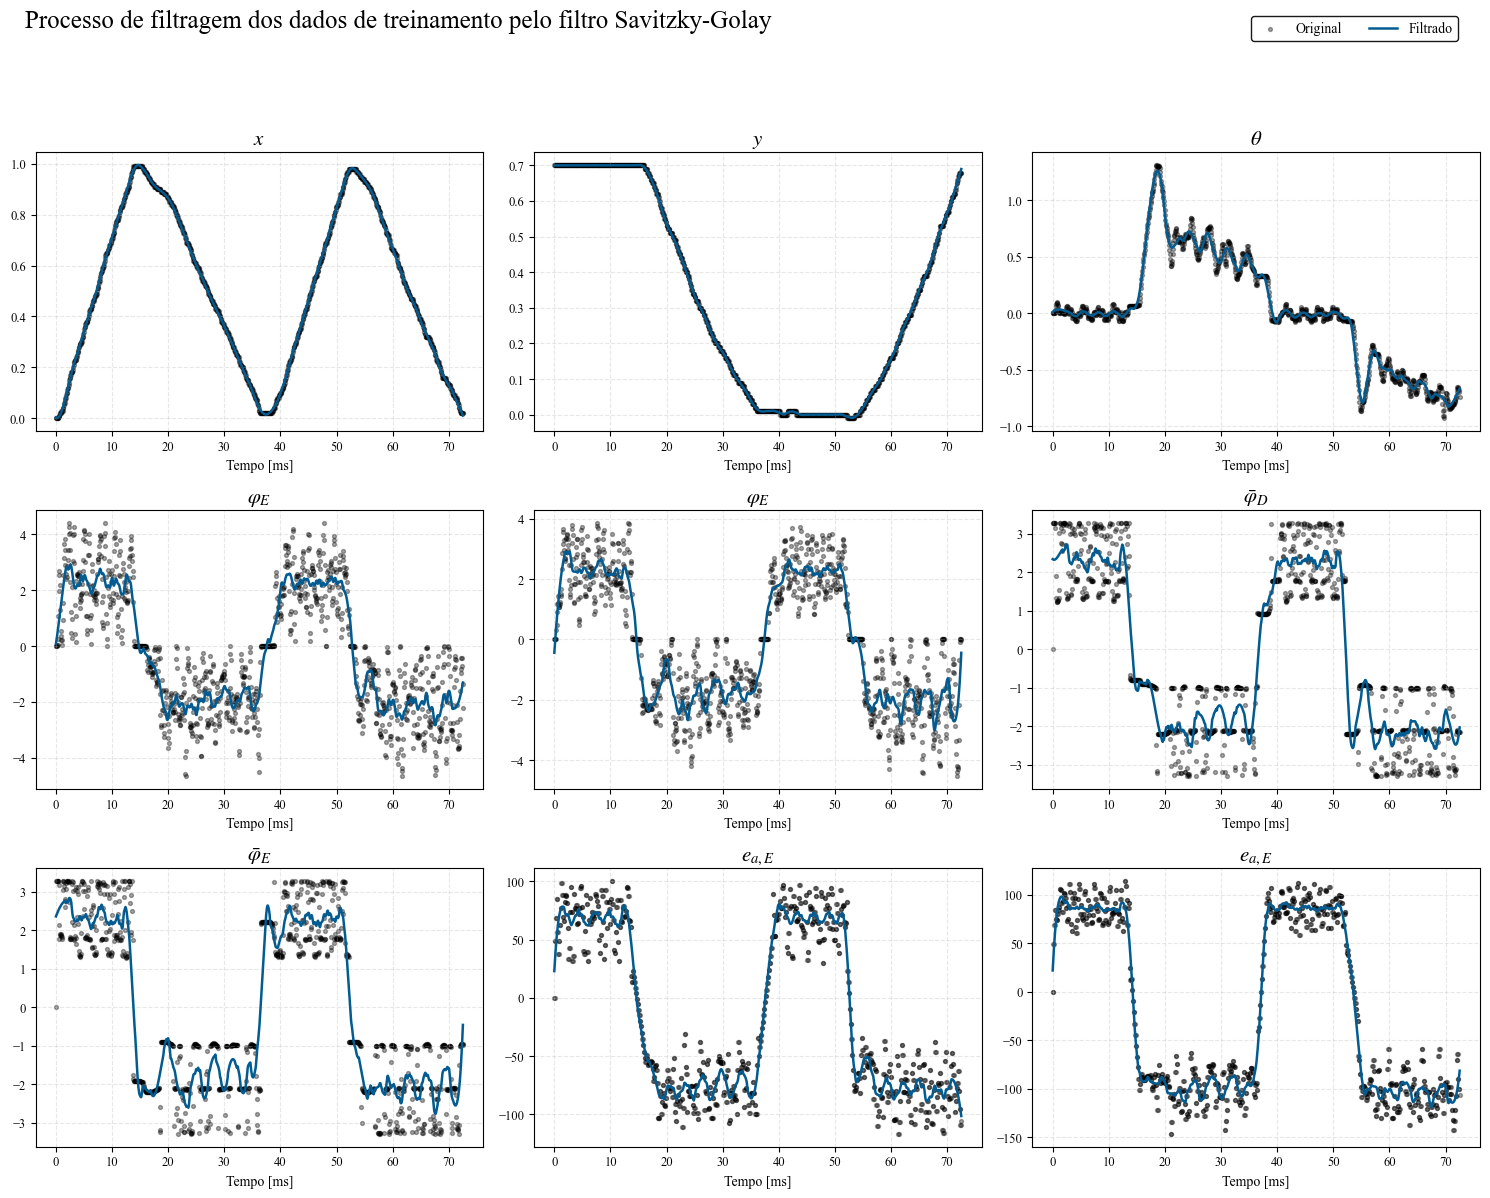


Figura criada com sucesso!
Arquivo: filtragem_dados_treinamento.pdf


In [7]:

from scipy.signal import savgol_filter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import math


# ============================================================
# PADRÃO VISUAL DO TCC
# ============================================================

mpl.rcParams.update({
    # Fonte
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Liberation Serif",
        "DejaVu Serif"
    ],
    "mathtext.fontset": "stix",

    # Tamanhos
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "figure.titlesize": 18,

    # Linhas
    "lines.linewidth": 1.3,
    "lines.markersize": 4,

    # Eixos e grid
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,

    # Legenda
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "black",

    # Exportação
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.dpi": 100,
})


# ============================================================
# CONFIGURAÇÃO
# ============================================================

TS = 0.07

FILE_PATH = "Datasets.xlsx"

OUTPUT_PDF = "filtragem_dados_treinamento.pdf"


# ============================================================
# DATASETS DE TREINAMENTO
# ============================================================

TRAINING_DATASETS = [
    "ZZx1",
]


# ============================================================
# VARIÁVEIS A SEREM ANALISADAS
# ============================================================

PARAMETROS_SAVGOL = {

    # Pose
    "x": (51, 3),
    "y": (51, 3),
    "theta": (51, 3),

    # Velocidade angular das rodas
    "phi_d": (51, 3),
    "phi_e": (51, 3),

    # Referências
    "phi_d_ref": (51, 3),
    "phi_e_ref": (51, 3),

    # Tensão
    "e_a_d": (51, 3),
    "e_a_e": (51, 3),
}


# ============================================================
# NOMES PARA EXIBIÇÃO NA FIGURA
# ============================================================

LABELS = {
    "x": r"$x$",
    "y": r"$y$",
    "theta": r"$\theta$",

    "phi_d": r"$\varphi_E$",
    "phi_e": r"$\varphi_E$",

    "phi_d_ref": r"$\bar{\varphi}_{D}$",
    "phi_e_ref": r"$\bar{\varphi}_{E}$",

    "e_a_d": r"$e_{a,E}$",
    "e_a_e": r"$e_{a,E}$",
}


# ============================================================
# CORES
# ============================================================

COLOR_ORIGINAL = "Black"
COLOR_FILTERED = "#025C91"


# ============================================================
# LEITURA DO ARQUIVO
# ============================================================

xls = pd.ExcelFile(FILE_PATH)

print("Abas encontradas:")
print(xls.sheet_names)


# ============================================================
# CRIA FIGURA
# ============================================================

n_vars = len(PARAMETROS_SAVGOL)

n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 12),
    squeeze=False
)

axs = axs.flatten()


# ============================================================
# LOOP DAS VARIÁVEIS
# ============================================================

for i, col in enumerate(PARAMETROS_SAVGOL.keys()):

    ax = axs[i]

    window, poly = PARAMETROS_SAVGOL[col]

    # --------------------------------------------------------
    # Plota os dois datasets de treinamento
    # --------------------------------------------------------

    for dataset_idx, title in enumerate(TRAINING_DATASETS):

        # Verifica se a aba existe
        if title not in xls.sheet_names:
            print(f"Aviso: aba '{title}' não encontrada.")
            continue

        # Lê dataset
        df = pd.read_excel(
            FILE_PATH,
            sheet_name=title
        )

        # Verifica coluna
        if col not in df.columns:
            print(
                f"Aviso: coluna '{col}' não encontrada "
                f"em '{title}'."
            )
            continue

        # ----------------------------------------------------
        # Dados
        # ----------------------------------------------------

        y = df[col].to_numpy(dtype=float)

        tempo = np.arange(len(y)) * TS

        # Remove NaN/Inf
        mask = np.isfinite(y)

        tempo = tempo[mask]
        y = y[mask]

        # ----------------------------------------------------
        # Ajuste da janela
        # ----------------------------------------------------

        current_window = window

        if current_window >= len(y):

            current_window = len(y)

            if current_window % 2 == 0:
                current_window -= 1

        if current_window <= poly:

            raise ValueError(
                f"Janela inválida para "
                f"{title}/{col}: "
                f"window={current_window}, "
                f"poly={poly}"
            )

        # ----------------------------------------------------
        # Tratamento de theta
        # ----------------------------------------------------

        if col == "theta":
            y_filter = np.unwrap(y)
        else:
            y_filter = y.copy()

        # ----------------------------------------------------
        # Savitzky-Golay
        # ----------------------------------------------------

        y_f = savgol_filter(
            y_filter,
            window_length=current_window,
            polyorder=poly
        )

        # ----------------------------------------------------
        # Retorna theta para [-pi, pi]
        # ----------------------------------------------------

        if col == "theta":

            y_f = (
                (y_f + np.pi)
                % (2 * np.pi)
            ) - np.pi

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        # Primeiro dataset:
        # Original = pontos
        # Filtrado = linha

        if dataset_idx == 0:

            ax.scatter(
                tempo,
                y,
                s=8,
                alpha=0.35,
                color=COLOR_ORIGINAL,
                label="Original"
            )

            ax.plot(
                tempo,
                y_f,
                linewidth=1.8,
                color=COLOR_FILTERED,
                label="Filtrado"
            )

        # Segundo dataset:
        # apenas como linha mais clara/tracejada
        # para não sobrecarregar a legenda

        else:

            ax.scatter(
                tempo,
                y,
                s=8,
                alpha=0.25,
                color=COLOR_ORIGINAL
            )

            ax.plot(
                tempo,
                y_f,
                linewidth=1.5,
                linestyle="--",
                color=COLOR_FILTERED
            )


# ============================================================
# CONFIGURAÇÃO DOS SUBPLOTS
# ============================================================

for i, col in enumerate(PARAMETROS_SAVGOL.keys()):

    ax = axs[i]

    ax.set_title(LABELS[col])

    ax.set_xlabel("Tempo [ms]")

    ax.grid(
        True,
        linestyle="--",
        alpha=0.3
    )


# ============================================================
# REMOVE SUBPLOTS VAZIOS
# ============================================================

for j in range(
    len(PARAMETROS_SAVGOL),
    len(axs)
):
    fig.delaxes(axs[j])


# ============================================================
# TÍTULO
# ============================================================

fig.suptitle(
    "Processo de filtragem dos dados de treinamento "
    "pelo filtro Savitzky-Golay",
    x=0.02,
    y=0.995,
    ha="left",
)


# ============================================================
# LEGENDA ÚNICA
# ============================================================

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.995),
    ncol=2,
)


# ============================================================
# AJUSTE FINAL
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)


# ============================================================
# EXPORTA PARA PDF
# ============================================================

plt.savefig(
    OUTPUT_PDF,
    format="pdf"
)


plt.show()


print("\n========================================")
print("Figura criada com sucesso!")
print(f"Arquivo: {OUTPUT_PDF}")
print("========================================")